In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')
import uproot
from tqdm import tqdm
import h5py
import uproot
import awkward as ak
import vector

# Background sample

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"

fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43']

with open(f"{base}/rd/RD/root_order.txt","r") as f:
    rfiles = f.read().splitlines()

nbkg_per = []
bkg_files = []
for rf in rfiles:
    with uproot.open(f"{base}/rd/RD/{rf}")['output'] as t:
        lab = t['label'].array().to_numpy()
        bkg_files.append(rf)
        nbkg_per.append(np.count_nonzero(lab==0))
        branches = list(t.keys())

with h5py.File(f_ind_rd,'r') as f:
    idx = f['test_inds'][()]
    
px = []
py = []
pz = []
e = []
j1_pt = []
for i,bf in enumerate(rfiles):
    with uproot.open(f"{base}/rd/RD/{bf}")['output'] as t:
        label = t['label'].array().to_numpy()
        mask = label==0
        px.append(t['c1_px'].array()[mask])
        py.append(t['c1_py'].array()[mask])
        pz.append(t['c1_pz'].array()[mask])
        e.append(t['c1_e'].array()[mask])
        j1_pt.append(t['jet1_pt'].array()[mask])
px = ak.concatenate(px,axis=0)
py = ak.concatenate(py,axis=0)
pz = ak.concatenate(pz,axis=0)
e = ak.concatenate(e,axis=0)
j1_pt = ak.concatenate(j1_pt,axis=0)

with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    j1_pt_ref = frd['jet1_pt'][()][mask]
    j1_eta_ref = frd['jet1_eta'][()][mask]
    j1_phi_ref = frd['jet1_phi'][()][mask]
    j1_m_ref = frd['jet1_m'][()][mask]
    keys = list(frd.keys())
    
px = px[idx]
py = py[idx]
pz = pz[idx]
e = e[idx]
j1_pt = j1_pt[idx]
j1_pt_ref = j1_pt_ref[idx]
j1_eta_ref = j1_eta_ref[idx]
j1_phi_ref = j1_phi_ref[idx]
j1_m_ref = j1_m_ref[idx]

pt = np.sqrt(px**2+py**2)

In [3]:
np.all(j1_pt==j1_pt_ref)

True

In [4]:
sort = ak.argsort(pt,axis=1,ascending=False)

px = px[sort]
py = py[sort]
pz = pz[sort]
e = e[sort]
pt = pt[sort]

px = ak.fill_none(ak.pad_none(px, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()
py = ak.fill_none(ak.pad_none(py, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()
pz = ak.fill_none(ak.pad_none(pz, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()
e = ak.fill_none(ak.pad_none(e, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()

In [5]:
j1_vec = vector.awk(ak.zip({"pt":j1_pt_ref.reshape(-1,1),"eta":j1_eta_ref.reshape(-1,1),"phi":j1_phi_ref.reshape(-1,1),"m":j1_m_ref.reshape(-1,1)}))
p_vec = vector.awk(ak.zip({"px":px,"py":py,"pz":pz,"e":e}))

In [6]:
pt = p_vec.pt.to_numpy()
eta = p_vec.deltaeta(j1_vec).to_numpy()
phi = p_vec.deltaphi(j1_vec).to_numpy()
z = pt/j1_pt_ref.reshape(-1,1)
e = p_vec.e.to_numpy()
ze = e/j1_vec.e.to_numpy()

mask = e==0
pt[mask] = 0.0
eta[mask] = 0.0
phi[mask] = 0.0
z[mask] = 0.0
e[mask] = 0.0
ze[mask] = 0.0

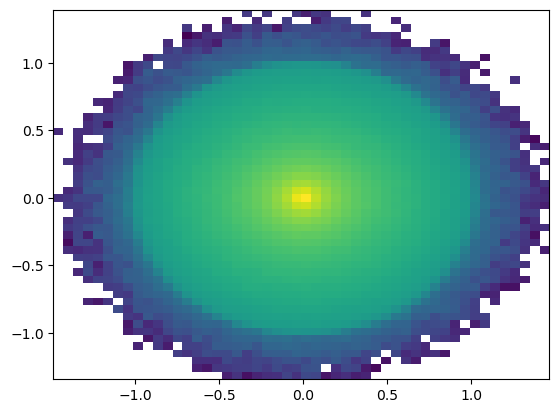

In [7]:
from matplotlib.colors import LogNorm
h=plt.hist2d(eta.flatten(),phi.flatten(),bins=50,weights=z.flatten(),norm=LogNorm())

In [8]:
toCopy = ['jet1_pt','jet1_eta','jet1_phi','jet1_m','jet1_tau21','jet1_tau32','jet1_tau43']
with h5py.File(f"{base}/rd/RD/bkg_particleNet_test_sample.h5","w") as fout:
    fout.create_dataset('cpt',data=pt)
    fout.create_dataset('ceta',data=eta)
    fout.create_dataset('cphi',data=phi)
    fout.create_dataset('ce',data=e)
    fout.create_dataset('cz',data=z)
    fout.create_dataset('cze',data=ze)
    with h5py.File(f_rd,"r") as frd:
        label = frd['label'][()]
        mask = label==0
        for c in toCopy:
            q = frd[c][()][mask][idx]
            fout.create_dataset(c,data=q)

# Signal sample

In [10]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"

with open(f"{base}/rd/RD/root_order.txt","r") as f:
    rfiles = f.read().splitlines()
    
px = []
py = []
pz = []
e = []
j1_pt = []
for i,bf in enumerate(rfiles):
    with uproot.open(f"{base}/rd/RD/{bf}")['output'] as t:
        label = t['label'].array().to_numpy()
        mask = label==1
        px.append(t['c1_px'].array()[mask])
        py.append(t['c1_py'].array()[mask])
        pz.append(t['c1_pz'].array()[mask])
        e.append(t['c1_e'].array()[mask])
        j1_pt.append(t['jet1_pt'].array()[mask])
px = ak.concatenate(px,axis=0)
py = ak.concatenate(py,axis=0)
pz = ak.concatenate(pz,axis=0)
e = ak.concatenate(e,axis=0)
j1_pt = ak.concatenate(j1_pt,axis=0)

with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==1
    j1_pt_ref = frd['jet1_pt'][()][mask]
    j1_eta_ref = frd['jet1_eta'][()][mask]
    j1_phi_ref = frd['jet1_phi'][()][mask]
    j1_m_ref = frd['jet1_m'][()][mask]
    keys = list(frd.keys())

pt = np.sqrt(px**2+py**2)

In [11]:
np.all(j1_pt==j1_pt_ref)

True

In [12]:
sort = ak.argsort(pt,axis=1,ascending=False)

px = px[sort]
py = py[sort]
pz = pz[sort]
e = e[sort]
pt = pt[sort]

px = ak.fill_none(ak.pad_none(px, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()
py = ak.fill_none(ak.pad_none(py, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()
pz = ak.fill_none(ak.pad_none(pz, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()
e = ak.fill_none(ak.pad_none(e, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()

In [13]:
j1_vec = vector.awk(ak.zip({"pt":j1_pt_ref.reshape(-1,1),"eta":j1_eta_ref.reshape(-1,1),"phi":j1_phi_ref.reshape(-1,1),"m":j1_m_ref.reshape(-1,1)}))
p_vec = vector.awk(ak.zip({"px":px,"py":py,"pz":pz,"e":e}))

In [14]:
pt = p_vec.pt.to_numpy()
eta = p_vec.deltaeta(j1_vec).to_numpy()
phi = p_vec.deltaphi(j1_vec).to_numpy()
z = pt/j1_pt_ref.reshape(-1,1)
e = p_vec.e.to_numpy()
ze = e/j1_vec.e.to_numpy()

mask = e==0
pt[mask] = 0.0
eta[mask] = 0.0
phi[mask] = 0.0
z[mask] = 0.0
e[mask] = 0.0
ze[mask] = 0.0

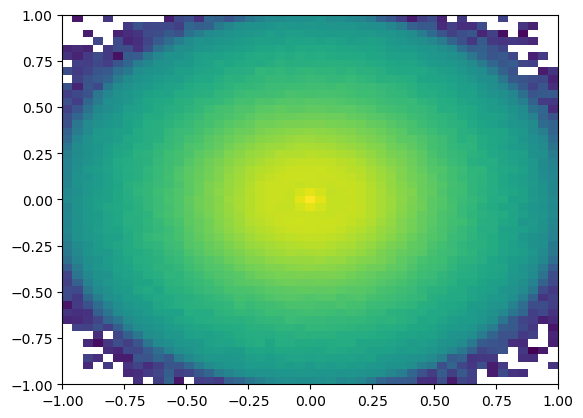

In [15]:
from matplotlib.colors import LogNorm
h=plt.hist2d(eta.flatten(),phi.flatten(),bins=np.linspace(-1,1,50),norm=LogNorm(),weights=z.flatten())

In [16]:
nsig = px.shape[0]
itrain,itest = train_test_split(np.arange(nsig),train_size=0.5,random_state=90101)
itest,ival = train_test_split(itest,train_size=0.5,random_state=41388)
with h5py.File(f"{base}/rd/RD/sig_split_indices.h5","w") as fout:
    fout.create_dataset("train_inds",data=itrain)
    fout.create_dataset("test_inds",data=itest)
    fout.create_dataset("val_inds",data=ival)

In [19]:
np.all(j1_pt[ival]==j1_pt_ref[ival])

True

In [20]:
toCopy = ['jet1_pt','jet1_eta','jet1_phi','jet1_m','jet1_tau21','jet1_tau32','jet1_tau43']
with h5py.File(f"{base}/rd/RD/sig_particleNet_val_sample.h5","w") as fout:
    fout.create_dataset('cpt',data=pt[ival])
    fout.create_dataset('ceta',data=eta[ival])
    fout.create_dataset('cphi',data=phi[ival])
    fout.create_dataset('ce',data=e[ival])
    fout.create_dataset('cz',data=z[ival])
    fout.create_dataset('cze',data=ze[ival])
    with h5py.File(f_rd,"r") as frd:
        label = frd['label'][()]
        mask = label==1
        for c in toCopy:
            q = frd[c][()][mask][ival]
            fout.create_dataset(c,data=q)

# BB1 Sample

In [9]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_rd = f"{base}/challenge/BB1/merged.h5"
f_ind_rd = f"{base}/challenge/BB1/split_indices.h5"

fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43']

with open(f"{base}/challenge/BB1/root_order.txt","r") as f:
    rfiles = f.read().splitlines()

with h5py.File(f_ind_rd,'r') as f:
    idx = f['test_inds'][()]
    
label = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
px = []
py = []
pz = []
e = []
j1_pt = []
nbkg_processed = 0
for i,bf in enumerate(rfiles):
    with uproot.open(f"{base}/challenge/BB1/{bf}")['output'] as t:
        n = t.num_entries
        lab = label[nbkg_processed:nbkg_processed+n]
        nbkg_processed += n
        mask = lab==0
        px.append(t['c1_px'].array()[mask])
        py.append(t['c1_py'].array()[mask])
        pz.append(t['c1_pz'].array()[mask])
        e.append(t['c1_e'].array()[mask])
        j1_pt.append(t['jet1_pt'].array()[mask])
px = ak.concatenate(px,axis=0)
py = ak.concatenate(py,axis=0)
pz = ak.concatenate(pz,axis=0)
e = ak.concatenate(e,axis=0)
j1_pt = ak.concatenate(j1_pt,axis=0)

with h5py.File(f_rd,"r") as frd:
    mask = label==0
    j1_pt_ref = frd['jet1_pt'][()][mask]
    j1_eta_ref = frd['jet1_eta'][()][mask]
    j1_phi_ref = frd['jet1_phi'][()][mask]
    j1_m_ref = frd['jet1_m'][()][mask]
    keys = list(frd.keys())
    
px = px[idx]
py = py[idx]
pz = pz[idx]
e = e[idx]
j1_pt = j1_pt[idx]
j1_pt_ref = j1_pt_ref[idx]
j1_eta_ref = j1_eta_ref[idx]
j1_phi_ref = j1_phi_ref[idx]
j1_m_ref = j1_m_ref[idx]

pt = np.sqrt(px**2+py**2)

In [10]:
np.all(j1_pt==j1_pt_ref)

True

In [11]:
sort = ak.argsort(pt,axis=1,ascending=False)

px = px[sort]
py = py[sort]
pz = pz[sort]
e = e[sort]
pt = pt[sort]

px = ak.fill_none(ak.pad_none(px, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()
py = ak.fill_none(ak.pad_none(py, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()
pz = ak.fill_none(ak.pad_none(pz, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()
e = ak.fill_none(ak.pad_none(e, 200, axis=1, clip=True), 0.0, axis=1).to_numpy()

In [12]:
j1_vec = vector.awk(ak.zip({"pt":j1_pt_ref.reshape(-1,1),"eta":j1_eta_ref.reshape(-1,1),"phi":j1_phi_ref.reshape(-1,1),"m":j1_m_ref.reshape(-1,1)}))
p_vec = vector.awk(ak.zip({"px":px,"py":py,"pz":pz,"e":e}))

In [13]:
pt = p_vec.pt.to_numpy()
eta = p_vec.deltaeta(j1_vec).to_numpy()
phi = p_vec.deltaphi(j1_vec).to_numpy()
z = pt/j1_pt_ref.reshape(-1,1)
e = p_vec.e.to_numpy()
ze = e/j1_vec.e.to_numpy()

mask = e==0
pt[mask] = 0.0
eta[mask] = 0.0
phi[mask] = 0.0
z[mask] = 0.0
e[mask] = 0.0
ze[mask] = 0.0

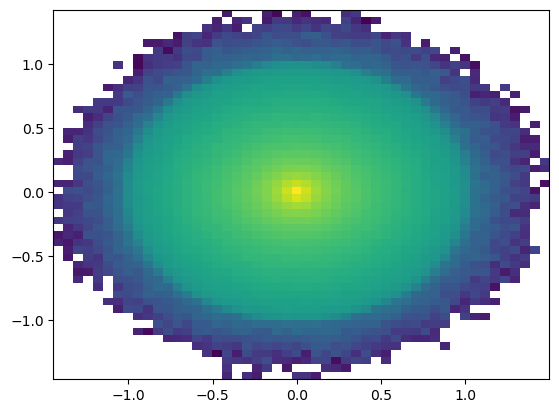

In [14]:
from matplotlib.colors import LogNorm
h=plt.hist2d(eta.flatten(),phi.flatten(),bins=50,weights=z.flatten(),norm=LogNorm())

In [15]:
toCopy = ['jet1_pt','jet1_eta','jet1_phi','jet1_m','jet1_tau21','jet1_tau32','jet1_tau43']
label = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
with h5py.File(f"{base}/challenge/BB1/bkg_particleNet_test_sample.h5","w") as fout:
    fout.create_dataset('cpt',data=pt)
    fout.create_dataset('ceta',data=eta)
    fout.create_dataset('cphi',data=phi)
    fout.create_dataset('ce',data=e)
    fout.create_dataset('cz',data=z)
    fout.create_dataset('cze',data=ze)
    with h5py.File(f_rd,"r") as frd:
        mask = label==0
        for c in toCopy:
            q = frd[c][()][mask][idx]
            fout.create_dataset(c,data=q)